# Generations of music cities: a formation-year coverage experiment

## tl;dr

The frozen MusicBrainz captures provide formation years for
**108/200 bands
(54%)** in the balanced top-20 catalogue.
Only **4 of 20 FUAs**
have complete coverage, while **2** have none.
The observed years span **1959–
2018**. Coverage lets us inspect the available
cohorts, but severe gaps rule out a city ranking by generation.

## Context and methods

The study review proposes comparing generations of music cities by band
formation decade. This first experiment extracts formation years only from
the repository's frozen MusicBrainz search and resolution captures. It joins
by MusicBrainz ID first and uses exact-name fallback only within the dedicated
top-20 resolution capture.

### Assumptions

Formation year is treated as a band-level cohort marker. Current Spotify
followers and listeners are not interpreted as audience at the time of
formation. Missing years are not treated as zero bands, and no city ranking is
reported because completeness differs sharply by FUA.

## Data

Attach frozen formation years and measure coverage before examining decades.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src/python_uk_bands").exists():
    ROOT = next(
        parent for parent in Path.cwd().resolve().parents
        if (parent / "src/python_uk_bands").exists()
    )
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ARTIFACT_DIR = ROOT / "artifacts/experiments/generations_by_decade/20260718T204522Z"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from python_uk_bands.review_experiments import (
    build_top20_generation_analysis,
    plot_decade_heatmap,
    plot_formation_year_coverage,
)

bands, formation_coverage, decade_summary, overall = (
    build_top20_generation_analysis(ROOT)
)

assert len(bands) == 200
assert formation_coverage["selected_bands"].eq(10).all()
assert formation_coverage["formation_year_coverage"].between(0, 1).all()
assert int(formation_coverage["bands_with_year"].sum()) == overall["bands_with_year"]

bands.to_csv(ARTIFACT_DIR / "band_formation_year_audit.csv", index=False)
formation_coverage.to_csv(
    ARTIFACT_DIR / "formation_year_coverage.csv", index=False
)
decade_summary.to_csv(ARTIFACT_DIR / "formation_decade_summary.csv", index=False)
(ARTIFACT_DIR / "coverage_summary.json").write_text(
    json.dumps(overall, indent=2, sort_keys=True) + "\n"
)

display(Markdown(
    f"**{overall['bands_with_year']}/{overall['selected_bands']} formation "
    f"years observed ({overall['formation_year_coverage']:.0%}) · "
    f"{overall['cities_with_complete_years']} complete FUAs · "
    f"{overall['cities_with_no_years']} FUAs with no observed years**"
))

**108/200 formation years observed (54%) · 4 complete FUAs · 2 FUAs with no observed years**

## Results

### 1. Is coverage adequate for a city comparison?

study_city_label,selected_bands,bands_with_year,formation_year_coverage
Glasgow,10,10,100%
Leeds,10,10,100%
Manchester,10,10,100%
Sheffield,10,10,100%
Birmingham,10,9,90%
Liverpool,10,9,90%
London,10,9,90%
Nottingham,10,8,80%
Bristol,10,5,50%
Coventry,10,4,40%


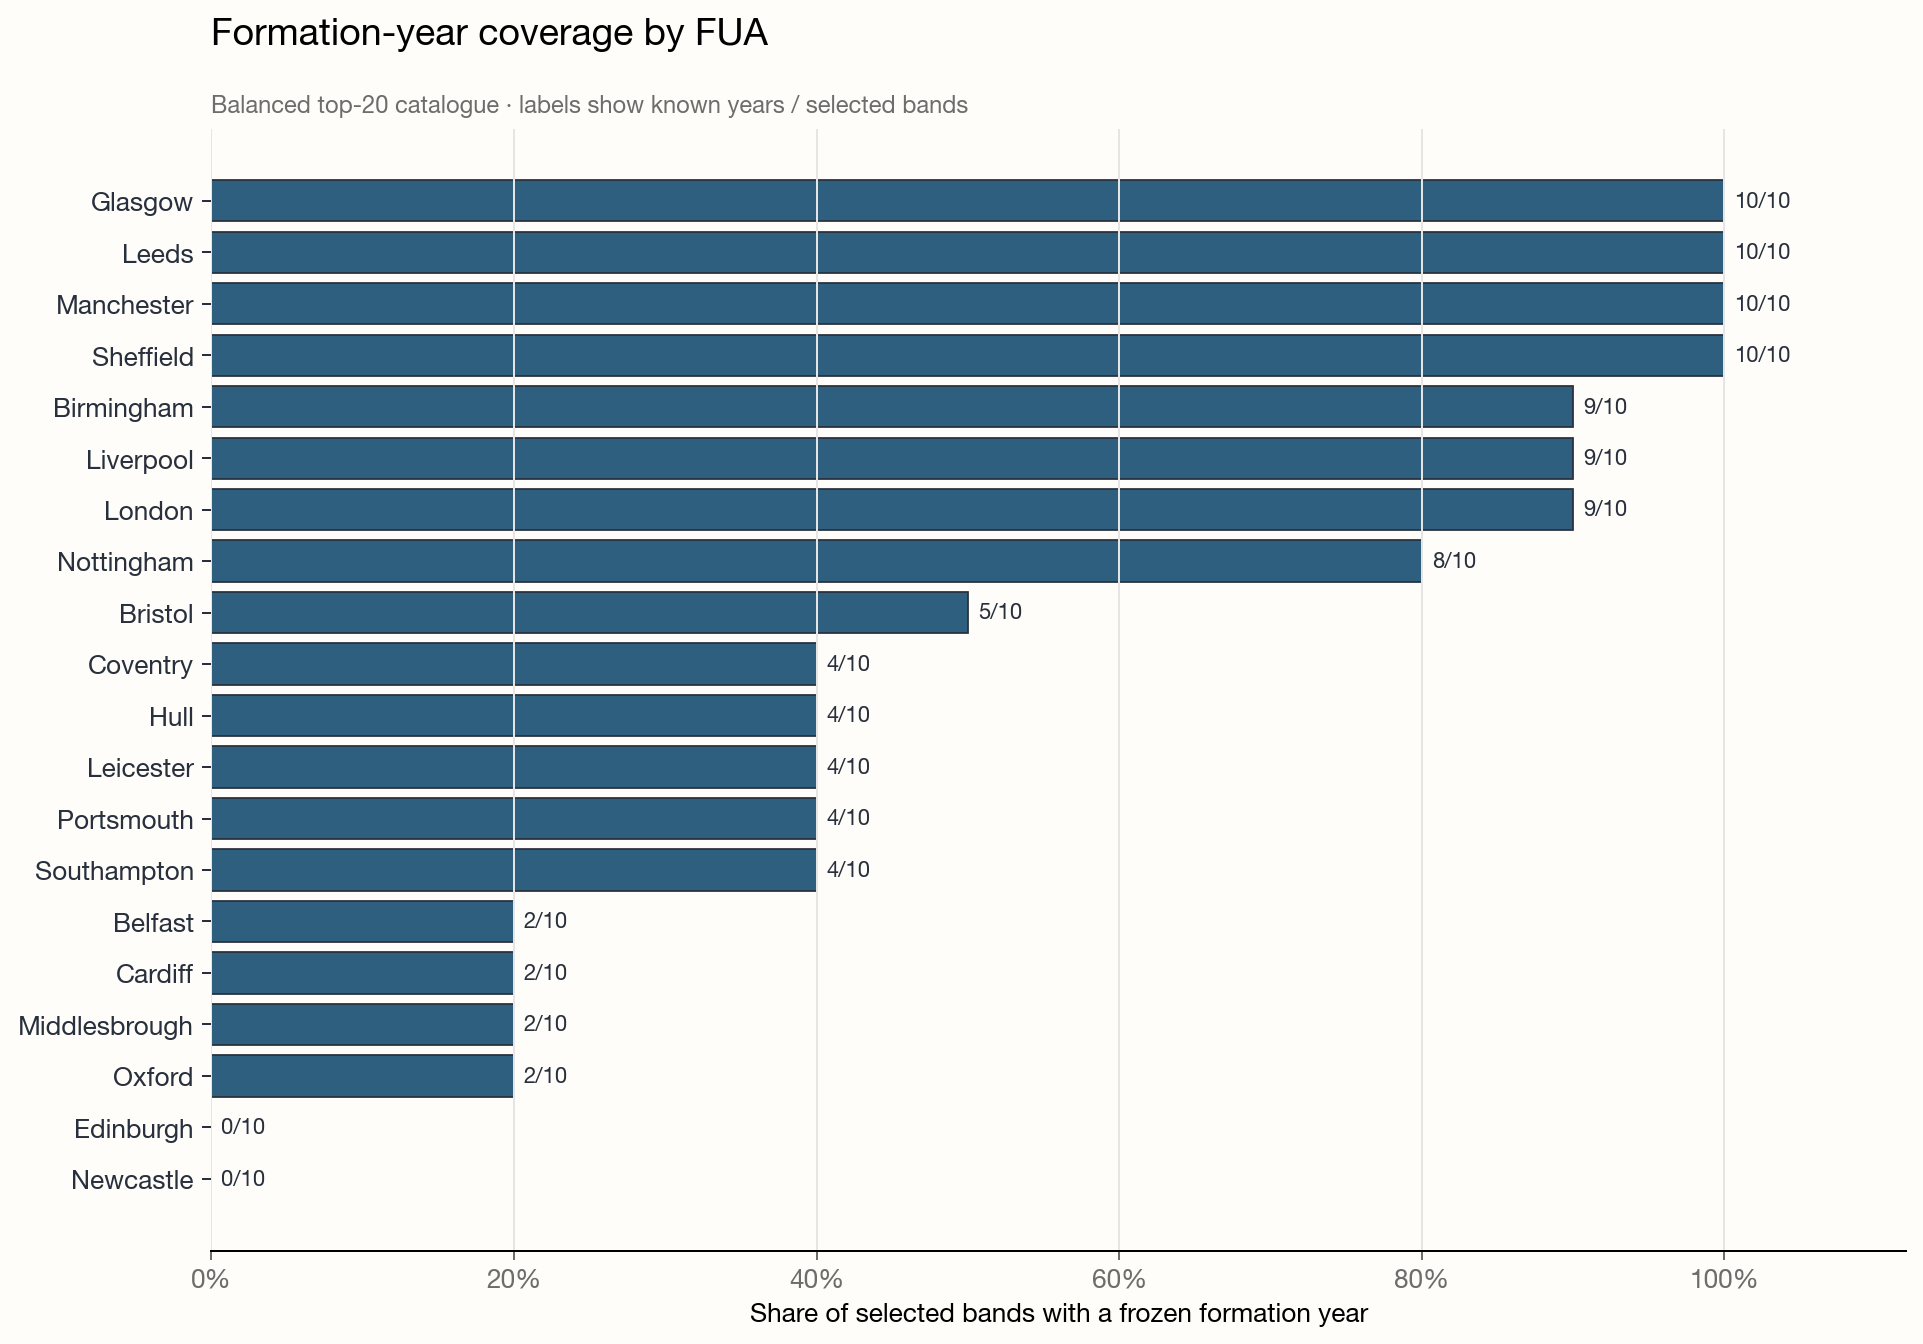

In [3]:
display(formation_coverage.style.hide(axis="index").format({
    "formation_year_coverage": "{:.0%}",
}))

coverage_path = plot_formation_year_coverage(
    formation_coverage,
    output_path=ARTIFACT_DIR / "chart_01_formation_year_coverage.png",
)
display(Image(filename=str(coverage_path)))

### 2. What formation decades are visible in the available data?

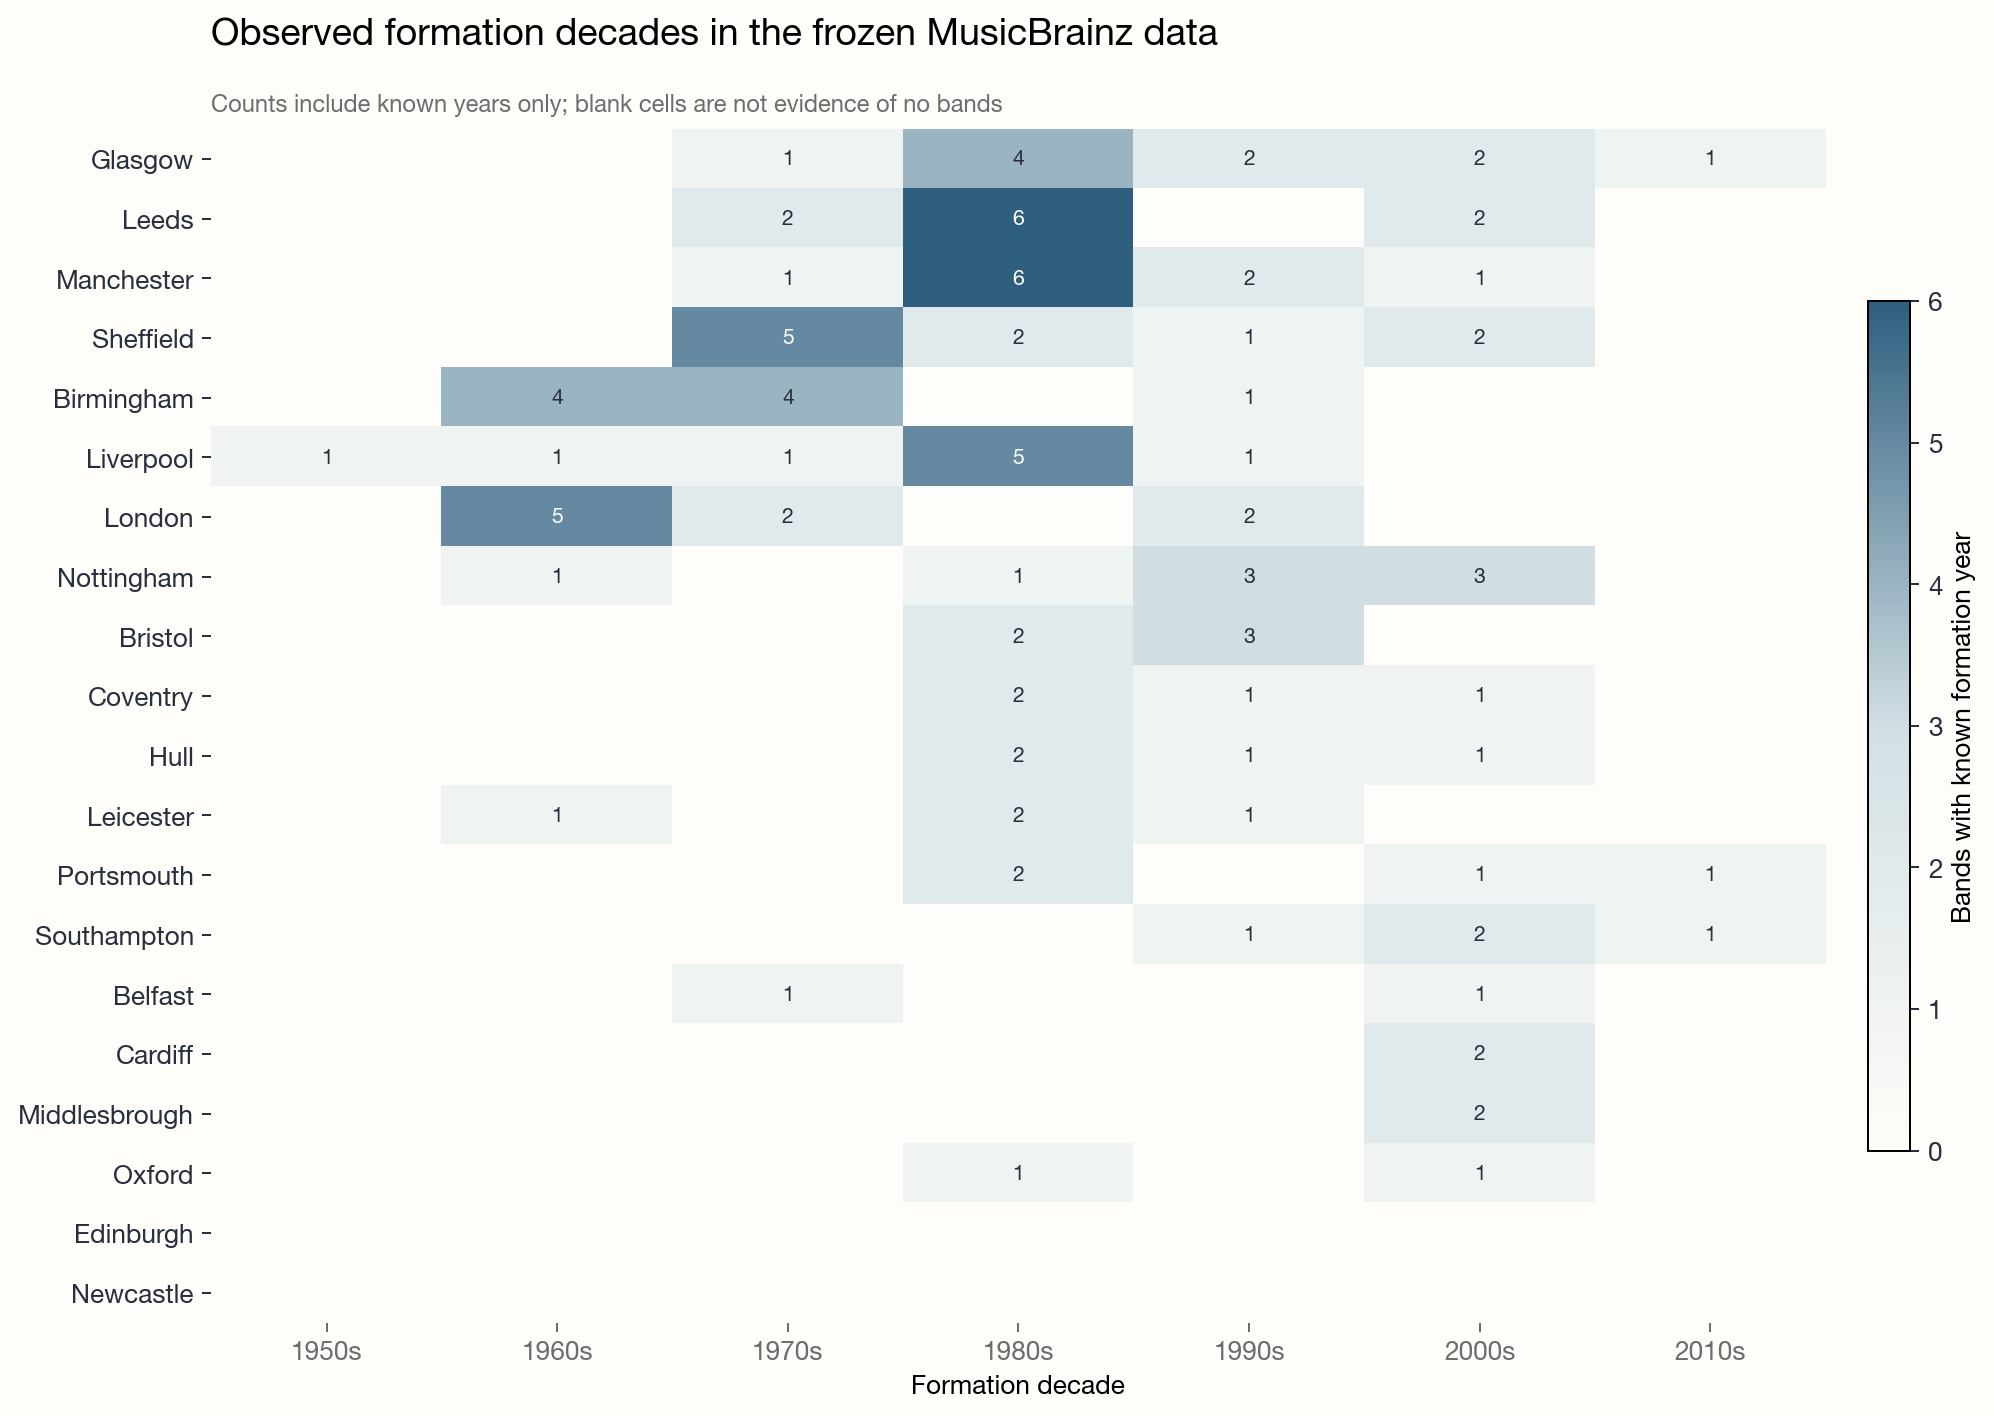

study_city_label,formation_decade,bands_with_known_year,followers,monthly_listeners
Liverpool,1950,1,"313,722","1,163,214"
London,1960,5,"58,183,928","118,779,436"
Liverpool,1960,1,"32,385,954","37,927,636"
Birmingham,1960,4,"17,273,261","25,618,930"
Nottingham,1960,1,"656,932","2,124,380"
Leicester,1960,1,"16,653","11,707"
London,1970,2,"61,513,024","66,190,701"
Birmingham,1970,4,"11,875,887","50,792,402"
Sheffield,1970,5,"9,460,586","21,824,359"
Manchester,1970,1,"2,965,374","4,140,711"


In [4]:
heatmap_path = plot_decade_heatmap(
    bands,
    formation_coverage,
    output_path=ARTIFACT_DIR / "chart_02_observed_formation_decades.png",
)
display(Image(filename=str(heatmap_path)))

display(decade_summary.sort_values(
    ["formation_decade", "followers"], ascending=[True, False]
).head(30).style.hide(axis="index").format({
    "followers": "{:,.0f}",
    "monthly_listeners": "{:,.0f}",
}))

## Takeaways

- The repository does not yet support a defensible generational city ranking.
- Coverage is complete for Glasgow, Leeds, Manchester and Sheffield, but zero
  for Edinburgh and Newcastle and only 20% for several other FUAs.
- The observed-decade heatmap is descriptive evidence about the captured
  records, not evidence that blank city-decades produced no bands.
- Before ranking generations, add a reviewed `formed_year` field for all 200
  bands and period-appropriate population denominators.